In [1]:
import torch
import functools
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision.datasets import MNIST
from tqdm import tqdm
from models import UNet_Tranformer, AutoEncoder, Latent_UNet_Tranformer
from utils import marginal_prob_std, diffusion_coeff, Euler_Maruyama_sampler, MyDataset

In [ ]:
import os
current_directory = os.getcwd()
print(current_directory)

## DDPM

In [ ]:
sigma =  25.0#@param {'type':'number'}

marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

# Load the pre-trained checkpoint from disk.
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
ckpt = torch.load('ckpt_rotated_STI_ddpm_mse_100e.pth', map_location=device)
# ckpt = torch.load('ckpt_rotated_with_label_STI_ddpm_mse_250e.pth', map_location=device)
score_model = torch.nn.DataParallel(UNet_Tranformer(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)
score_model.load_state_dict(ckpt)
score_model.eval()

# Set params
sample_batch_size = 16 #@param {'type':'integer'}
num_steps = 100 #@param {'type':'integer'}
sampler = Euler_Maruyama_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
%matplotlib inline
plt.figure(figsize=(10, 4))

# for i, digit in enumerate(range(10)):
samples = sampler(score_model,
        marginal_prob_std_fn,
        diffusion_coeff_fn,
        num_steps,
        sample_batch_size,
        device=device,
        y=45*torch.ones(sample_batch_size, dtype=torch.long))

    ## Sample visualization.
samples = samples.clamp(0.0, 1.0)
sample_grid = make_grid(samples, nrow=int(np.sqrt(sample_batch_size)))

# plt.subplot(2, 5, i+1)
plt.title(f"Angle: 45")
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)

plt.tight_layout()
plt.show()

In [ ]:
sigma =  25.0#@param {'type':'number'}

marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

# Load the pre-trained checkpoint from disk.
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
ckpt = torch.load('model_objects/ckpt_mnist_ddpm_100e.pth', map_location=device)
score_model = torch.nn.DataParallel(UNet_Tranformer(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)
score_model.load_state_dict(ckpt)
score_model.eval()

# Set params
sample_batch_size = 16 #@param {'type':'integer'}
num_steps_list = [10, 50, 100, 200, 500, 1000] #@param {'type':'integer'}
sampler = Euler_Maruyama_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
%matplotlib inline
plt.figure(figsize=(10, 4))

digit = 4
for i, num_steps in enumerate(num_steps_list):
    samples = sampler(score_model,
            marginal_prob_std_fn,
            diffusion_coeff_fn,
            num_steps,
            sample_batch_size,
            device=device,
            y=digit*torch.ones(sample_batch_size, dtype=torch.long))
    
    ## Sample visualization.
    samples = samples.clamp(0.0, 1.0)
    sample_grid = make_grid(samples, nrow=int(np.sqrt(sample_batch_size)))

    plt.subplot(1, len(num_steps_list), i+1)
    plt.title(f"Steps: {num_steps}")
    plt.axis('off')
    plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.tight_layout()
plt.show()

## AutoEncoder

Total parameters: 4,137
Trainable parameters: 4,137
Non-trainable parameters: 0
-----------------------------
torch.Size([128, 1, 128, 128])
False


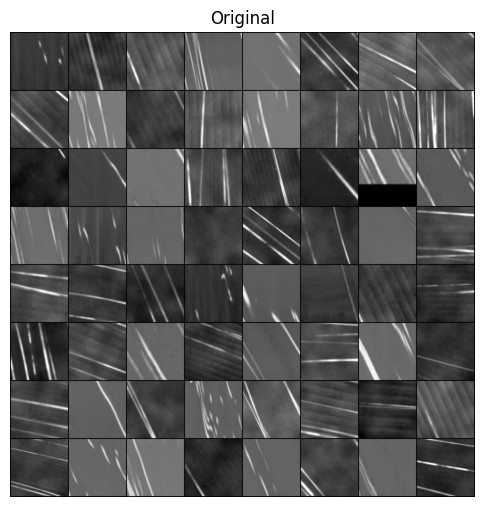

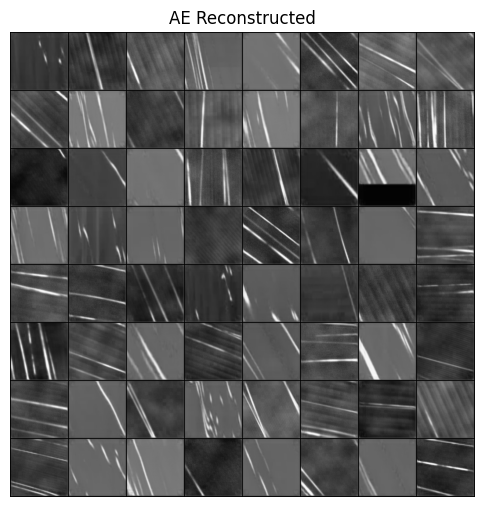

In [2]:
#@title Visualize trained autoencoder
# Load model
device = 'cuda'
ckpt = torch.load(r'..\model_objects\ckpt_synth_mix_STI_mse_100e.pth', map_location=device)
ae_model = AutoEncoder([4, 8, 16]).cuda()
ae_model = ae_model.to(device)
ae_model.load_state_dict(ckpt)
ae_model.eval()

total_params = sum(p.numel() for p in ae_model.decoder.parameters())
trainable_params = sum(p.numel() for p in ae_model.decoder.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")
print("-----------------------------")

# Prep dataloader
batch_size =  128
# dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
# data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

labels = np.load(r'../data/master_labels.npy')
data = np.load(r'../data/master_data_labeled.npy')
labels = np.round(labels)
synth_labels = np.load(r'../data/synth_labels.npy', allow_pickle=True)
synth_data = np.load(r'../data/synth_grayscale_images.npy')

labels = np.concat((labels, synth_labels))
data = np.concat((data, synth_data))

labels = torch.from_numpy(labels)
data = torch.from_numpy(data)

data = data/255

labels = labels.long()
data = data.float()

dataset = MyDataset(data, labels)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)    


# Get next batch
x, y = next(iter(data_loader))
print(x.shape)
x_hat = ae_model(x.to(device)).cpu().detach()

print(id(x) == id(x_hat))

plt.figure(figsize=(6,6.5))
plt.axis('off')
plt.imshow(make_grid(x[:64,:,:,:].cpu()).permute([1,2,0]), vmin=0., vmax=1.)
plt.title("Original")
plt.show()

plt.figure(figsize=(6,6.5))
plt.axis('off')
plt.imshow(make_grid(x_hat[:64,:,:,:].cpu()).permute([1,2,0]), vmin=0., vmax=1.)
plt.title("AE Reconstructed")
plt.show()

## LDM

100%|██████████| 500/500 [00:11<00:00, 43.15it/s]


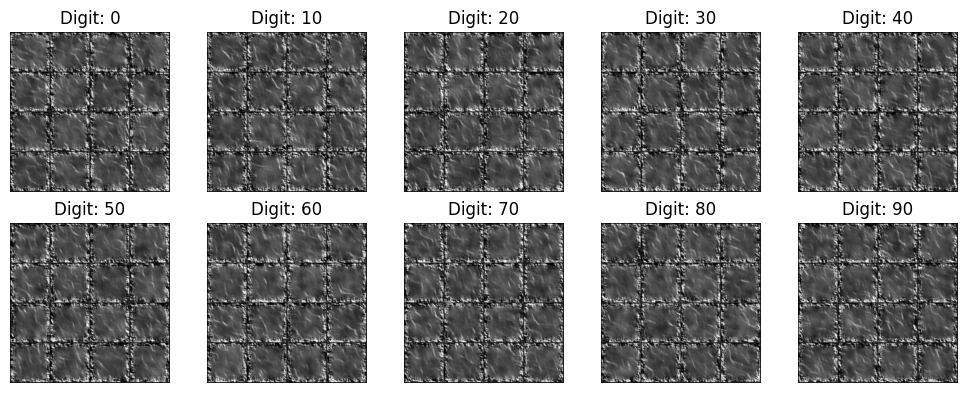

In [3]:
sigma =  25.0#@param {'type':'number'}
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

# Load latent diffusion model
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
ckpt = torch.load(r'..\model_objects\ckpt_synth_mix_STI_ldm_0.001_100e.pth', map_location=device)
score_model = torch.nn.DataParallel(Latent_UNet_Tranformer(marginal_prob_std=marginal_prob_std_fn, channels = [16, 64, 128, 256]))
score_model = score_model.to(device)
score_model.load_state_dict(ckpt)
score_model.eval()


# Load autoencoder model
ae_ckpt = torch.load(r'..\model_objects\ckpt_synth_mix_STI_mse_100e.pth', map_location=device)
ae_model = AutoEncoder([4, 8, 16]).cuda()
ae_model = ae_model.to(device)
ae_model.load_state_dict(ae_ckpt)
ae_model.eval()

# Set params
sample_batch_size = 16 #@param {'type':'integer'}
num_steps = 500 #@param {'type':'integer'}
sampler = Euler_Maruyama_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
%matplotlib inline
plt.figure(figsize=(10, 4))

for i, digit in enumerate(range(0, 91, 10)):
    samples = sampler(score_model,
            marginal_prob_std_fn,
            diffusion_coeff_fn,
            num_steps,
            sample_batch_size,
            device=device,
            x_shape=(16,56,56),
            y=digit*torch.ones(sample_batch_size, dtype=torch.long))

    ## Sample visualization.
    decoder_samples = ae_model.decoder(samples).clamp(0.0, 1.0)
    sample_grid = make_grid(decoder_samples, nrow=int(np.sqrt(sample_batch_size)))

    plt.subplot(2, 5, i+1)
    plt.title(f"Digit: {digit}")
    plt.axis('off')
    plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)

plt.tight_layout()
plt.show()

In [ ]:
# Set params
sample_batch_size = 16 #@param {'type':'integer'}
num_steps_list = [10, 50, 100, 200, 500, 1000] #@param {'type':'integer'}
sampler = Euler_Maruyama_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
%matplotlib inline
plt.figure(figsize=(10, 4))

digit = 4
for i, num_steps in enumerate(num_steps_list):
    samples = sampler(score_model,
            marginal_prob_std_fn,
            diffusion_coeff_fn,
            num_steps,
            sample_batch_size,
            device=device,
            x_shape=(4,10,10),
            y=digit*torch.ones(sample_batch_size, dtype=torch.long))

    ## Sample visualization.
    decoder_samples = ae_model.decoder(samples).clamp(0.0, 1.0)
    sample_grid = make_grid(decoder_samples, nrow=int(np.sqrt(sample_batch_size)))

    plt.subplot(1, len(num_steps_list), i+1)
    plt.title(f"Steps: {num_steps}")
    plt.axis('off')
    plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.tight_layout()
plt.show()